# 03 Deprivation Extension

This notebook links PTAL-valid housing records to the English Indices of Deprivation 2019 and summarises accessibility across deprivation quintiles.

## 1. Setup


In [4]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(".")
BASE = PROJECT_ROOT
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = OUTPUT_DIR / "pld_completed_housing_with_ptal_main_2015_2025.gpkg"

print("Base folder:", BASE)
print("Housing data exists:", DATA_PATH.exists())

Base folder: .
Housing data exists: True


## 2. Load final PTAL-matched housing dataset

In [5]:
analysis_gdf = gpd.read_file(DATA_PATH)

print("Rows loaded:", len(analysis_gdf))
print("Columns:")
print(analysis_gdf.columns.tolist())

# Keep only records with a valid PTAL assignment for PTAL-based analysis
analysis_gdf_ptal = analysis_gdf[
    analysis_gdf["PTAL_2023"].notna()
].copy()

print("\nRows with PTAL:", len(analysis_gdf_ptal))
print("Excluded rows without PTAL:", len(analysis_gdf) - len(analysis_gdf_ptal))
print(
    "Excluded units without PTAL:",
    analysis_gdf.loc[analysis_gdf["PTAL_2023"].isna(), "completed_units"].sum()
)

analysis_gdf_ptal.head()

Rows loaded: 25852
Columns:
['LPA Number', 'Borough', 'Valid date', 'Status', 'Application type', 'Description', 'Site name', 'Site number', 'Street name', 'Locality', 'Postcode', 'Actual commencement date', 'Actual completion date', 'Total number of proposed residential units', 'Total number of existing residential units', 'Units Proposed', 'Units Lost', 'Net Units', 'Net units with commencement date', 'Net units with completion date', 'Decision', 'Decision date', 'Appeal decision', 'Appeal decision date', 'URL planning application', 'source_file', 'completion_date', 'valid_date', 'completed_units', 'postcode_from_postcode_col', 'postcode_clean', 'postcode_source', 'completion_financial_year', 'completion_calendar_year', 'pcds', 'doterm', 'oseast1m', 'osnrth1m', 'lsoa11cd', 'lsoa21cd', '_merge', 'PTAL_2023', 'ptal_band', 'ptal_medium_high', 'ptal_high', 'index_right', 'borough_spatial', 'geometry']

Rows with PTAL: 25829
Excluded rows without PTAL: 23
Excluded units without PTAL: 347.

,LPA Number,Borough,Valid date,Status,Application type,Description,Site name,Site number,Street name,Locality,...,lsoa11cd,lsoa21cd,_merge,PTAL_2023,ptal_band,ptal_medium_high,ptal_high,index_right,borough_spatial,geometry
0,221164FUL,Ealing,17/03/2022,Completed,All Other,Change of use of single family dwellinghouse (...,65 Twyford Abbey Road,None,Twyford Abbey Road,London,...,E01001276,E01001276,both,4,Medium,True,False,4.0,Ealing,POINT (518888 182894)
1,10/03970/FULL,Westminster,None,Completed,All Other,Renewal of extant planning permission dated 02...,"Windsor House, 55-56","Windsor House, 55-56",St James's Street,None,...,E01004736,E01004736,both,6b,High,True,True,25.0,Westminster,POINT (529167 180313)
2,11/01869/RG4,Lambeth,None,Completed,All Other,Redevelopment of the site involving demolition...,Claremont East Housing Estate,Claremont East Housing Estate,Streatham Hill,None,...,E01003174,E01003174,both,4,Medium,True,False,15.0,Lambeth,POINT (531483 172994)
3,12/AP/3161,Southwark,None,Completed,All Other,Conversion of top floor maisonette into two se...,15,15,Risborough Street,None,...,E01003927,E01033867,both,6b,High,True,True,22.0,Southwark,POINT (531974 179986)
4,14/10040/FUL,Kingston upon Thames,None,Completed,All Other,Conversion of existing house into 1 x 3 bedroo...,28,28,WOODGATE AVENUE,None,...,E01002941,E01002941,both,1b,Low,False,False,0.0,Kingston upon Thames,POINT (517696 164444)


## 3. Load IMD / deprivation data

In [6]:
IMD_PATH = BASE / "ID 2019 for London.xlsx"

# First check all sheet names
xls = pd.ExcelFile(IMD_PATH)
print("Available sheets:")
print(xls.sheet_names)

# Read the actual IMD data sheet
imd_raw = pd.read_excel(
    IMD_PATH,
    sheet_name="IMD 2019"
)

print("IMD rows:", len(imd_raw))
print("IMD columns:")
print(imd_raw.columns.tolist())

imd_raw.head()

Available sheets:
['Notes', 'IMD 2019', 'Sub domains', 'IDACI and IDAOPI', 'Borough summary measures', 'Borough domain summaries', 'Borough IDACI IDAOPI', 'Population figures', 'Underlying indicators', 'Underlying indicators notes']
IMD rows: 4835
IMD columns:
['LSOA code (2011)', 'LSOA name (2011)', 'Local Authority District code (2019)', 'Local Authority District name (2019)', 'Index of Multiple Deprivation (IMD) Score', 'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)', 'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)', 'Income Score (rate)', 'Income Rank (where 1 is most deprived)', 'Income Decile (where 1 is most deprived 10% of LSOAs)', 'Employment Score (rate)', 'Employment Rank (where 1 is most deprived)', 'Employment Decile (where 1 is most deprived 10% of LSOAs)', 'Education, Skills and Training Score', 'Education, Skills and Training Rank (where 1 is most deprived)', 'Education, Skills and Training Decile (where 1 is mos

,LSOA code (2011),LSOA name (2011),Local Authority District code (2019),Local Authority District name (2019),Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Score (rate),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),...,Health Deprivation and Disability Decile (where 1 is most deprived 10% of LSOAs),Crime Score,Crime Rank (where 1 is most deprived),Crime Decile (where 1 is most deprived 10% of LSOAs),Barriers to Housing and Services Score,Barriers to Housing and Services Rank (where 1 is most deprived),Barriers to Housing and Services Decile (where 1 is most deprived 10% of LSOAs),Living Environment Score,Living Environment Rank (where 1 is most deprived),Living Environment Decile (where 1 is most deprived 10% of LSOAs)
0,E01000001,City of London 001A,E09000001,City of London,6.208,29199,9,0.007,32831,10,...,10,-2.012,32662,10,29.472,7319,3,31.873,7789,3
1,E01000002,City of London 001B,E09000001,City of London,5.143,30379,10,0.034,29901,10,...,10,-2.343,32789,10,24.412,11707,4,23.084,13070,4
2,E01000003,City of London 001C,E09000001,City of London,19.402,14915,5,0.086,18510,6,...,6,-1.032,29363,9,40.103,2157,1,40.535,4092,2
3,E01000005,City of London 001E,E09000001,City of London,28.652,8678,3,0.211,6029,2,...,6,-1.317,31059,10,39.900,2217,1,28.979,9397,3
4,E01032739,City of London 001F,E09000001,City of London,13.584,20391,7,0.014,32638,10,...,8,-1.560,31947,10,46.314,837,1,49.165,2040,1


## 4. Detect key IMD columns and create deprivation quintiles

In [7]:
def find_col_exact_or_contains(columns, exact_candidates, must_contain=None):
    # First try exact matching
    for c in exact_candidates:
        if c in columns:
            return c
    
    lower_map = {str(c).lower(): c for c in columns}
    for c in exact_candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    
    # Then try flexible contains matching
    if must_contain is not None:
        for col in columns:
            col_lower = str(col).lower()
            if all(term.lower() in col_lower for term in must_contain):
                return col
    
    return None


imd_cols = imd_raw.columns.tolist()

# LSOA code
imd_lsoa_col = find_col_exact_or_contains(
    imd_cols,
    [
        "LSOA code (2011)",
        "LSOA Code (2011)",
        "LSOA code",
        "LSOA Code",
        "lsoa11cd",
        "LSOA11CD",
        "lsoa21cd",
        "LSOA21CD"
    ],
    must_contain=["lsoa", "code"]
)

# IMD rank
imd_rank_col = find_col_exact_or_contains(
    imd_cols,
    [
        "Index of Multiple Deprivation (IMD) Rank",
        "IMD Rank",
        "Index of Multiple Deprivation Rank",
        "imd_rank",
        "IMD rank"
    ],
    must_contain=["deprivation", "rank"]
)

# IMD decile
imd_decile_col = find_col_exact_or_contains(
    imd_cols,
    [
        "Index of Multiple Deprivation (IMD) Decile",
        "IMD Decile",
        "Index of Multiple Deprivation Decile",
        "imd_decile",
        "IMD decile"
    ],
    must_contain=["deprivation", "decile"]
)

# IMD score
imd_score_col = find_col_exact_or_contains(
    imd_cols,
    [
        "Index of Multiple Deprivation (IMD) Score",
        "IMD Score",
        "Index of Multiple Deprivation Score",
        "imd_score",
        "IMD score"
    ],
    must_contain=["deprivation", "score"]
)

print("Detected IMD LSOA column:", imd_lsoa_col)
print("Detected IMD rank column:", imd_rank_col)
print("Detected IMD decile column:", imd_decile_col)
print("Detected IMD score column:", imd_score_col)

if imd_lsoa_col is None:
    raise ValueError(
        "Could not detect the IMD LSOA code column. Check imd_raw.columns and set imd_lsoa_col manually."
    )

if imd_rank_col is None and imd_decile_col is None and imd_score_col is None:
    raise ValueError(
        "Could not detect an IMD rank, decile or score column. Check imd_raw.columns and set the column manually."
    )

Detected IMD LSOA column: LSOA code (2011)
Detected IMD rank column: Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)
Detected IMD decile column: Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)
Detected IMD score column: Index of Multiple Deprivation (IMD) Score


In [8]:
# Standardise IMD table

imd = imd_raw.copy()

imd["lsoa_code_imd"] = (
    imd[imd_lsoa_col]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Keep useful IMD fields
keep_cols = ["lsoa_code_imd"]

if imd_rank_col is not None:
    imd["imd_rank"] = pd.to_numeric(imd[imd_rank_col], errors="coerce")
    keep_cols.append("imd_rank")

if imd_decile_col is not None:
    imd["imd_decile"] = pd.to_numeric(imd[imd_decile_col], errors="coerce")
    keep_cols.append("imd_decile")

if imd_score_col is not None:
    imd["imd_score"] = pd.to_numeric(imd[imd_score_col], errors="coerce")
    keep_cols.append("imd_score")

imd = imd[keep_cols].drop_duplicates(subset=["lsoa_code_imd"]).copy()

# Create quintile:
# 1 = most deprived, 5 = least deprived
if "imd_decile" in imd.columns:
    imd["imd_quintile"] = np.ceil(imd["imd_decile"] / 2).astype("Int64")
elif "imd_rank" in imd.columns:
    imd["imd_quintile"] = pd.qcut(
        imd["imd_rank"].rank(method="first"),
        q=5,
        labels=[1, 2, 3, 4, 5]
    ).astype("Int64")
else:
    # Higher IMD score means more deprived, so reverse-rank score before qcut
    imd["imd_quintile"] = pd.qcut(
        imd["imd_score"].rank(method="first", ascending=False),
        q=5,
        labels=[1, 2, 3, 4, 5]
    ).astype("Int64")

imd["imd_quintile_label"] = imd["imd_quintile"].map({
    1: "Q1 most deprived",
    2: "Q2",
    3: "Q3",
    4: "Q4",
    5: "Q5 least deprived"
})

print(imd.head())
print("\nIMD quintile counts:")
print(imd["imd_quintile_label"].value_counts(dropna=False).sort_index())

  lsoa_code_imd  imd_rank  imd_decile  imd_score  imd_quintile  \
0     E01000001     29199           9      6.208             5   
1     E01000002     30379          10      5.143             5   
2     E01000003     14915           5     19.402             3   
3     E01000005      8678           3     28.652             2   
4     E01032739     20391           7     13.584             4   

  imd_quintile_label  
0  Q5 least deprived  
1  Q5 least deprived  
2                 Q3  
3                 Q2  
4                 Q4  

IMD quintile counts:
imd_quintile_label
Q1 most deprived      795
Q2                   1472
Q3                   1091
Q4                    851
Q5 least deprived     626
Name: count, dtype: int64


## 5. Join housing records to IMD

In [9]:
# Detect housing LSOA column

housing_cols = analysis_gdf_ptal.columns.tolist()

housing_lsoa_candidates = [
    "lsoa11cd", "lsoa21cd", "lsoa_code", "LSOA11CD", "LSOA21CD", "LSOA code"
]

housing_lsoa_col = None

# Try to match likely IMD geography first
imd_lsoa_name_lower = str(imd_lsoa_col).lower()

if "2011" in imd_lsoa_name_lower or "11" in imd_lsoa_name_lower:
    preferred = ["lsoa11cd", "LSOA11CD"]
elif "2021" in imd_lsoa_name_lower or "21" in imd_lsoa_name_lower:
    preferred = ["lsoa21cd", "LSOA21CD", "lsoa_code"]
else:
    preferred = housing_lsoa_candidates

for c in preferred + housing_lsoa_candidates:
    if c in housing_cols:
        housing_lsoa_col = c
        break

print("Detected housing LSOA column:", housing_lsoa_col)

if housing_lsoa_col is None:
    print("Housing columns:")
    print(housing_cols)
    raise ValueError(
        "No LSOA code found in the housing dataset. "
        "Check whether notebook 01 retained lsoa11cd/lsoa21cd from ONSPD."
    )

# Avoid silently joining 2011 IMD to 2021 LSOAs
if ("2011" in imd_lsoa_name_lower or "11" in imd_lsoa_name_lower) and "21" in housing_lsoa_col.lower():
    raise ValueError(
        "The IMD file appears to use LSOA 2011 codes, but the housing dataset appears to use LSOA 2021 codes. "
        "Go back to notebook 01, add lsoa11cd to the ONSPD usecols, rerun notebook 01, then rerun this notebook."
    )

housing_imd = analysis_gdf_ptal.copy()
housing_imd["lsoa_code_for_imd"] = (
    housing_imd[housing_lsoa_col]
    .astype(str)
    .str.strip()
    .str.upper()
)

housing_imd = housing_imd.merge(
    imd,
    left_on="lsoa_code_for_imd",
    right_on="lsoa_code_imd",
    how="left"
)

print("Rows after IMD join:", len(housing_imd))
print("Rows with IMD:", housing_imd["imd_quintile"].notna().sum())
print("Rows without IMD:", housing_imd["imd_quintile"].isna().sum())

housing_imd.head()

Detected housing LSOA column: lsoa11cd
Rows after IMD join: 25829
Rows with IMD: 25829
Rows without IMD: 0


,LPA Number,Borough,Valid date,Status,Application type,Description,Site name,Site number,Street name,Locality,...,index_right,borough_spatial,geometry,lsoa_code_for_imd,lsoa_code_imd,imd_rank,imd_decile,imd_score,imd_quintile,imd_quintile_label
0,221164FUL,Ealing,17/03/2022,Completed,All Other,Change of use of single family dwellinghouse (...,65 Twyford Abbey Road,None,Twyford Abbey Road,London,...,4.0,Ealing,POINT (518888 182894),E01001276,E01001276,13885,5,20.560,3,Q3
1,10/03970/FULL,Westminster,None,Completed,All Other,Renewal of extant planning permission dated 02...,"Windsor House, 55-56","Windsor House, 55-56",St James's Street,None,...,25.0,Westminster,POINT (529167 180313),E01004736,E01004736,24862,8,9.719,4,Q4
2,11/01869/RG4,Lambeth,None,Completed,All Other,Redevelopment of the site involving demolition...,Claremont East Housing Estate,Claremont East Housing Estate,Streatham Hill,None,...,15.0,Lambeth,POINT (531483 172994),E01003174,E01003174,6425,2,33.582,1,Q1 most deprived
3,12/AP/3161,Southwark,None,Completed,All Other,Conversion of top floor maisonette into two se...,15,15,Risborough Street,None,...,22.0,Southwark,POINT (531974 179986),E01003927,E01003927,17545,6,16.421,3,Q3
4,14/10040/FUL,Kingston upon Thames,None,Completed,All Other,Conversion of existing house into 1 x 3 bedroo...,28,28,WOODGATE AVENUE,None,...,0.0,Kingston upon Thames,POINT (517696 164444),E01002941,E01002941,25233,8,9.426,4,Q4


In [10]:
IMD_JOINED_PATH = (
    OUTPUT_DIR /
    "pld_completed_housing_with_ptal_imd_2019.gpkg"
)

if IMD_JOINED_PATH.exists():
    IMD_JOINED_PATH.unlink()

housing_imd.to_file(
    IMD_JOINED_PATH,
    layer="housing_imd",
    driver="GPKG"
)

print("Saved record-level IMD file:")
print(IMD_JOINED_PATH)
print("Rows saved:", len(housing_imd))
print(
    "Rows without IMD:",
    housing_imd["imd_quintile"].isna().sum()
)

Saved record-level IMD file:
outputs\pld_completed_housing_with_ptal_imd_2019.gpkg
Rows saved: 25829
Rows without IMD: 0


In [11]:
# IMD match coverage

imd_matched = housing_imd["imd_quintile"].notna()

imd_coverage_summary = pd.DataFrame({
    "category": [
        "PTAL-matched housing records",
        "Matched to IMD",
        "Missing IMD after LSOA join"
    ],
    "records": [
        len(housing_imd),
        int(imd_matched.sum()),
        int((~imd_matched).sum())
    ],
    "completed_units": [
        housing_imd["completed_units"].sum(),
        housing_imd.loc[imd_matched, "completed_units"].sum(),
        housing_imd.loc[~imd_matched, "completed_units"].sum()
    ]
})

imd_coverage_summary["record_share"] = (
    imd_coverage_summary["records"] / len(housing_imd)
)

imd_coverage_summary["unit_share"] = (
    imd_coverage_summary["completed_units"] / housing_imd["completed_units"].sum()
)

imd_coverage_summary.to_csv(
    OUTPUT_DIR / "summary_imd_join_coverage.csv",
    index=False
)

imd_coverage_summary

,category,records,completed_units,record_share,unit_share
0,PTAL-matched housing records,25829,225104.0,1.0,1.0
1,Matched to IMD,25829,225104.0,1.0,1.0
2,Missing IMD after LSOA join,0,0.0,0.0,0.0


## 6. IMD quintile × PTAL band

In [12]:
# IMD quintile × PTAL band summary

housing_imd_valid = housing_imd[
    housing_imd["imd_quintile"].notna() &
    housing_imd["ptal_band"].notna()
].copy()

imd_order = [
    "Q1 most deprived",
    "Q2",
    "Q3",
    "Q4",
    "Q5 least deprived"
]

ptal_order = ["Low", "Medium", "High"]

housing_imd_valid["imd_quintile_label"] = housing_imd_valid["imd_quintile"].map({
    1: "Q1 most deprived",
    2: "Q2",
    3: "Q3",
    4: "Q4",
    5: "Q5 least deprived"
})

housing_imd_valid["imd_quintile_label"] = pd.Categorical(
    housing_imd_valid["imd_quintile_label"],
    categories=imd_order,
    ordered=True
)

housing_imd_valid["ptal_band"] = pd.Categorical(
    housing_imd_valid["ptal_band"],
    categories=ptal_order,
    ordered=True
)

imd_ptal_summary = (
    housing_imd_valid
    .groupby(["imd_quintile", "imd_quintile_label", "ptal_band"], observed=True)
    .agg(
        records=("LPA Number", "count"),
        completed_units=("completed_units", "sum")
    )
    .reset_index()
    .sort_values(["imd_quintile", "ptal_band"])
)

imd_ptal_summary.to_csv(
    OUTPUT_DIR / "summary_imd_quintile_by_ptal_band.csv",
    index=False
)

imd_ptal_summary

,imd_quintile,imd_quintile_label,ptal_band,records,completed_units
0,1,Q1 most deprived,Low,864,9607.0
1,1,Q1 most deprived,Medium,1256,11380.0
2,1,Q1 most deprived,High,1320,20545.0
3,2,Q2,Low,2346,20993.0
4,2,Q2,Medium,3313,27570.0
5,2,Q2,High,2863,40795.0
6,3,Q3,Low,2367,17049.0
7,3,Q3,Medium,2548,19737.0
8,3,Q3,High,1729,17993.0
9,4,Q4,Low,2007,10546.0


In [13]:
# Pivot table: completed units by IMD quintile and PTAL band

imd_ptal_units_pivot = imd_ptal_summary.pivot_table(
    index="imd_quintile_label",
    columns="ptal_band",
    values="completed_units",
    aggfunc="sum",
    fill_value=0,
    observed=False
).reindex(index=imd_order, columns=ptal_order)

imd_ptal_units_pivot

ptal_band,Low,Medium,High
imd_quintile_label,,,
Q1 most deprived,9607.0,11380.0,20545.0
Q2,20993.0,27570.0,40795.0
Q3,17049.0,19737.0,17993.0
Q4,10546.0,8384.0,8517.0
Q5 least deprived,5264.0,5006.0,1718.0


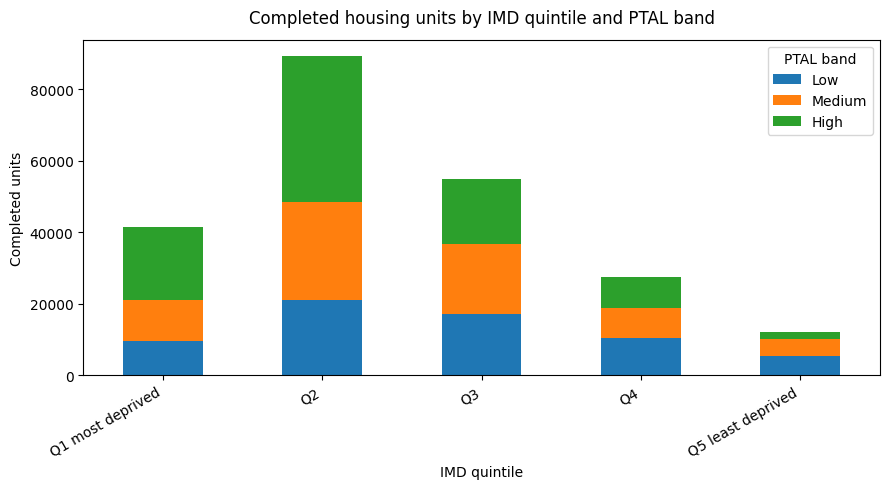

In [14]:
# Figure 11: completed units by IMD quintile and PTAL band

fig, ax = plt.subplots(figsize=(9, 5))

imd_ptal_units_pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title("Completed housing units by IMD quintile and PTAL band", fontsize=12, pad=12)
ax.set_xlabel("IMD quintile")
ax.set_ylabel("Completed units")
ax.legend(title="PTAL band")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(FIG_DIR / "fig11_units_by_imd_quintile_ptal_band.png", dpi=300)
plt.show()

## 7. Medium/High PTAL completions by IMD quintile

In [15]:
# Medium/High PTAL completions by IMD quintile

imd_accessibility = (
    housing_imd_valid
    .groupby("imd_quintile", observed=True)
    .agg(
        records=("LPA Number", "count"),
        completed_units=("completed_units", "sum"),
        units_medium_high=(
            "completed_units",
            lambda x: x[housing_imd_valid.loc[x.index, "ptal_medium_high"]].sum()
        ),
        units_high=(
            "completed_units",
            lambda x: x[housing_imd_valid.loc[x.index, "ptal_high"]].sum()
        )
    )
    .reset_index()
)

imd_accessibility["imd_quintile_label"] = imd_accessibility["imd_quintile"].map({
    1: "Q1 most deprived",
    2: "Q2",
    3: "Q3",
    4: "Q4",
    5: "Q5 least deprived"
})

imd_accessibility["share_units_medium_high"] = (
    imd_accessibility["units_medium_high"] / imd_accessibility["completed_units"]
)

imd_accessibility["share_units_high"] = (
    imd_accessibility["units_high"] / imd_accessibility["completed_units"]
)

imd_accessibility = imd_accessibility.sort_values("imd_quintile").copy()

imd_accessibility.to_csv(
    OUTPUT_DIR / "summary_imd_accessibility_share.csv",
    index=False
)

imd_accessibility

,imd_quintile,records,completed_units,units_medium_high,units_high,imd_quintile_label,share_units_medium_high,share_units_high
0,1,3440,41532.0,31925.0,20545.0,Q1 most deprived,0.768684,0.494679
1,2,8522,89358.0,68365.0,40795.0,Q2,0.765069,0.456534
2,3,6644,54779.0,37730.0,17993.0,Q3,0.688768,0.328465
3,4,4487,27447.0,16901.0,8517.0,Q4,0.615769,0.310307
4,5,2736,11988.0,6724.0,1718.0,Q5 least deprived,0.560894,0.143310


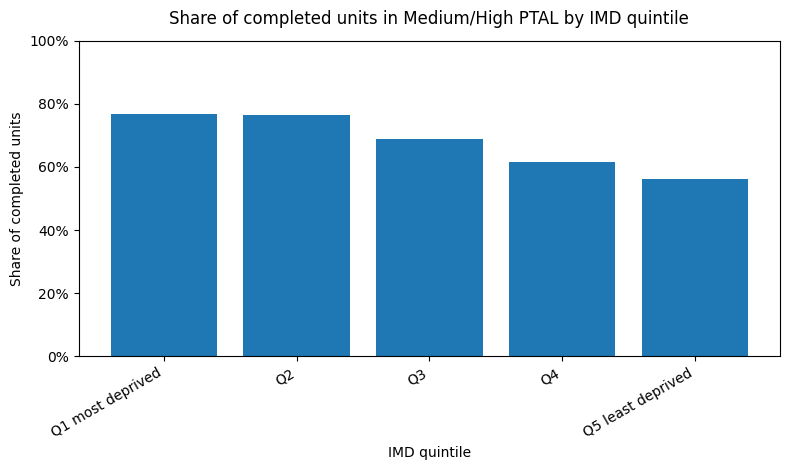

In [16]:
# Figure 12: share of units in Medium/High PTAL by IMD quintile

fig, ax = plt.subplots(figsize=(8, 4.8))

plot_data = (
    imd_accessibility
    .drop_duplicates(subset=["imd_quintile_label"])
    .set_index("imd_quintile_label")
    .reindex(imd_order)
)

ax.bar(
    plot_data.index.astype(str),
    plot_data["share_units_medium_high"]
)

ax.set_title("Share of completed units in Medium/High PTAL by IMD quintile", fontsize=12, pad=12)
ax.set_xlabel("IMD quintile")
ax.set_ylabel("Share of completed units")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(FIG_DIR / "fig12_share_medium_high_ptal_by_imd_quintile.png", dpi=300)
plt.show()

## 8. Borough-level deprivation context

In [17]:
def weighted_mean(values, weights):
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")
    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])

borough_imd_rows = []

for borough, group in housing_imd_valid.dropna(subset=["borough_spatial"]).groupby("borough_spatial"):
    total_units = group["completed_units"].sum()
    units_medium_high = group.loc[group["ptal_medium_high"], "completed_units"].sum()
    units_high = group.loc[group["ptal_high"], "completed_units"].sum()

    borough_imd_rows.append({
        "borough_spatial": borough,
        "records": len(group),
        "completed_units": total_units,
        "units_medium_high": units_medium_high,
        "share_units_medium_high": units_medium_high / total_units if total_units > 0 else np.nan,
        "units_high": units_high,
        "share_units_high": units_high / total_units if total_units > 0 else np.nan,
        "weighted_mean_imd_quintile": weighted_mean(group["imd_quintile"], group["completed_units"]),
        "median_imd_quintile": group["imd_quintile"].median()
    })

borough_imd_summary = pd.DataFrame(borough_imd_rows).sort_values(
    "share_units_medium_high",
    ascending=False
)

borough_imd_summary.to_csv(
    OUTPUT_DIR / "summary_borough_imd_accessibility.csv",
    index=False
)

borough_imd_summary.head(10)

,borough_spatial,records,completed_units,units_medium_high,share_units_medium_high,units_high,share_units_high,weighted_mean_imd_quintile,median_imd_quintile
6,City of London,37,540.0,540.0,1.000000,540.0,1.000000,3.427778,4.0
32,Westminster,837,7432.0,7400.0,0.995694,6394.0,0.860334,2.633073,3.0
18,Islington,262,1880.0,1792.0,0.953191,1592.0,0.846809,2.051064,2.0
21,Lambeth,954,7057.0,6474.0,0.917387,4955.0,0.702140,1.816636,2.0
5,Camden,705,5563.0,5009.0,0.900413,4112.0,0.739170,2.603092,3.0
27,Southwark,930,8759.0,7741.0,0.883777,5331.0,0.608631,2.071127,2.0
10,Greenwich,307,3544.0,3075.0,0.867664,1203.0,0.339447,2.166761,2.0
11,Hackney,1149,7491.0,6339.0,0.846215,3613.0,0.482312,1.644373,2.0
3,Brent,1101,12664.0,10716.0,0.846178,5762.0,0.454991,2.105733,2.0
31,Wandsworth,1174,12758.0,10704.0,0.839003,6242.0,0.489262,2.978367,3.0


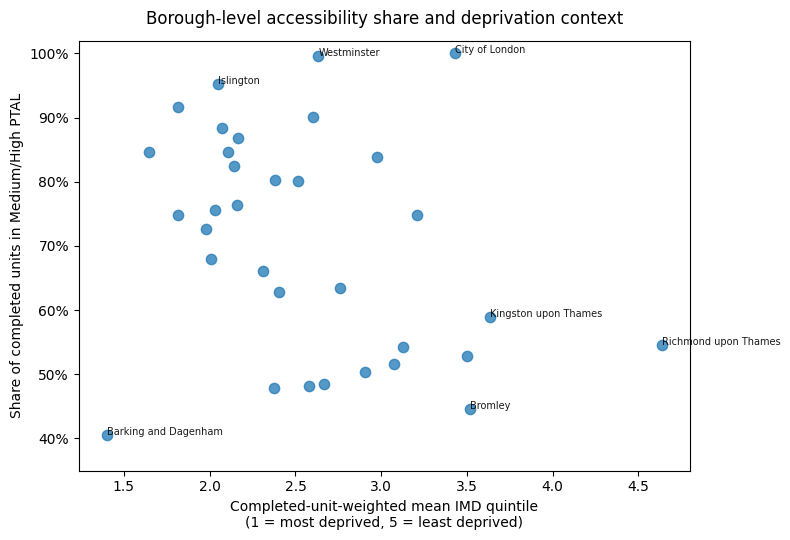

In [18]:
# Figure 13: borough-level accessibility share and deprivation context

plot_df = borough_imd_summary.dropna(
    subset=["weighted_mean_imd_quintile", "share_units_medium_high", "completed_units"]
).copy()

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.scatter(
    plot_df["weighted_mean_imd_quintile"],
    plot_df["share_units_medium_high"],
    s=55,
    alpha=0.75
)

# Label only selected boroughs to reduce clutter
label_boroughs = [
    "Barking and Dagenham",
    "Richmond upon Thames",
    "City of London",
    "Westminster",
    "Islington",
    "Bromley",
    "Kingston upon Thames"
]

for _, row in plot_df[plot_df["borough_spatial"].isin(label_boroughs)].iterrows():
    ax.annotate(
        row["borough_spatial"],
        (row["weighted_mean_imd_quintile"], row["share_units_medium_high"]),
        fontsize=7,
        alpha=0.9
    )

ax.set_title("Borough-level accessibility share and deprivation context", fontsize=12, pad=12)
ax.set_xlabel("Completed-unit-weighted mean IMD quintile\n(1 = most deprived, 5 = least deprived)")
ax.set_ylabel("Share of completed units in Medium/High PTAL")

# Zoom in to the observed range instead of showing full 0–100%
ax.set_ylim(0.35, 1.02)
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

plt.tight_layout()

plt.savefig(FIG_DIR / "fig13_borough_accessibility_imd_context.png", dpi=300)
plt.show()

## 9. Result summary

In [19]:
overall_units = housing_imd_valid["completed_units"].sum()
overall_medium_high_units = housing_imd_valid.loc[
    housing_imd_valid["ptal_medium_high"],
    "completed_units"
].sum()

print("IMD-valid completed units:", overall_units)
print("Medium/High PTAL units:", overall_medium_high_units)
print("Medium/High PTAL share:", overall_medium_high_units / overall_units)

print("\nIMD accessibility table:")
display(imd_accessibility)

print("\nSuggested interpretation checks:")
print("- Does Q1/Q2 have a higher or lower Medium/High PTAL share than Q4/Q5?")
print("- Are completed units concentrated in deprived quintiles, less deprived quintiles, or evenly distributed?")
print("- Do borough-level patterns support or complicate the overall IMD quintile pattern?")

IMD-valid completed units: 225104.0
Medium/High PTAL units: 161645.0
Medium/High PTAL share: 0.7180903049257232

IMD accessibility table:


,imd_quintile,records,completed_units,units_medium_high,units_high,imd_quintile_label,share_units_medium_high,share_units_high
0,1,3440,41532.0,31925.0,20545.0,Q1 most deprived,0.768684,0.494679
1,2,8522,89358.0,68365.0,40795.0,Q2,0.765069,0.456534
2,3,6644,54779.0,37730.0,17993.0,Q3,0.688768,0.328465
3,4,4487,27447.0,16901.0,8517.0,Q4,0.615769,0.310307
4,5,2736,11988.0,6724.0,1718.0,Q5 least deprived,0.560894,0.143310



Suggested interpretation checks:
- Does Q1/Q2 have a higher or lower Medium/High PTAL share than Q4/Q5?
- Are completed units concentrated in deprived quintiles, less deprived quintiles, or evenly distributed?
- Do borough-level patterns support or complicate the overall IMD quintile pattern?
